# Adding a factor to an existing portfolio

Most desks already run a multi-factor book. This notebook shows what happens
when you fold **one more factor** into it: how the candidate factor relates to
the book you already hold, and how the blend's risk and return shift before and
after.

The "existing book" here is a real multi-factor portfolio, built with the same
recipe as
[Multi-Factor Portfolio Construction](00_multi_factor_portfolio_construction.ipynb)
(point-in-time universe -> cross-sectional factor bins -> inverse-volatility
weighting -> backtest). That machinery is tucked into the collapsed cell below
so the rest of the notebook stays about the integration. By default the book is
six of the seven **AF-COMP** constituents and the factor we add is **Retail
Flow** -- so adding it reconstructs the full 7 Factor Composite.

**Prerequisites: none** -- runs on the shared public demo key (preview data);
set `APERIODIC_API_KEY` for full data. Licence: MIT.

In [1]:
# Self-contained install for Colab / a fresh venv (a no-op if you cloned the repo
# and ran `pip install -r requirements.txt`). Runs first so the imports in the
# collapsed helper cell below resolve on a fresh environment.
import sys

!{sys.executable} -m pip install -q aperiodic-factors python-dotenv matplotlib numpy pandas

In [2]:
# --- Portfolio construction (collapsed) --------------------------------------
# Everything needed to turn a set of factors into a backtested book, inlined so
# the notebook is self-contained. Same recipe as the multi-factor notebook: rank
# each factor cross-sectionally into signed weights, average the factors, size by
# inverse volatility, cap per name, then run a lagged, cost-aware vectorized
# backtest. Expand only if you want the mechanics -- the integration story lives
# in the cells below.
import os
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from dotenv import load_dotenv

import aperiodic_factors as aperiodic

DEMO_API_KEY = "DEMO-KEY"


def get_api_key() -> str:
    # A Google Colab secret, then a local .env / environment variable, then the
    # shared public demo key (preview data) so the notebook runs with no signup.
    try:
        from google.colab import userdata

        try:
            return userdata.get("APERIODIC_API_KEY") or DEMO_API_KEY
        except Exception:  # noqa: BLE001 -- secret not set / access denied
            return DEMO_API_KEY
    except ImportError:
        try:
            load_dotenv()
        except Exception:  # noqa: BLE001
            warnings.warn("Could not load .env")  # noqa: B028
        return os.environ.get("APERIODIC_API_KEY") or DEMO_API_KEY


def _signed_bins(factor: pd.DataFrame, quantiles: int = 20) -> pd.DataFrame:
    # Rank each date's cross-section into quantile bins, then map to long/short
    # weights spanning [-1, 1] at unit gross exposure.
    binned = factor.apply(
        lambda row: pd.qcut(row, q=quantiles, labels=False, duplicates="drop"),
        axis="columns",
    )
    weights = binned.div(binned.max(axis="columns"), axis="index").mul(2).sub(1)
    return weights.div(weights.abs().sum(axis="columns"), axis="index")


def _inverse_vol(
    returns: pd.DataFrame, weights: pd.DataFrame, period: int = 120
) -> pd.DataFrame:
    # Down-weight high-volatility names so each contributes comparable risk.
    stds = returns.rolling(period, min_periods=0).std().where(weights.notna())
    inv = 1 / stds.div(stds.sum(axis="columns"), axis="index")
    inv[inv == np.inf] = 0.0
    return inv.div(inv.sum(axis="columns"), axis="index").mul(
        weights.count(axis="columns"), axis="index"
    )


def _backtest(
    weights: pd.DataFrame, returns: pd.DataFrame, cost: float = 0.0005, lag: int = 1
) -> pd.Series:
    # Lagged, transaction-cost-aware vectorized backtest -> daily book returns.
    weights = weights.reindex(returns.index).ffill().fillna(0.0)
    turnover = weights.diff().abs().fillna(0.0)
    return (returns * weights.shift(lag) - cost * turnover).sum(axis="columns")


def load_inputs(factor_ids, universe_size, start_date, end_date, api_key):
    # Fetch the point-in-time universe, prices and each factor's raw history once,
    # so the book can be rebuilt from any subset of the factors without re-hitting
    # the API.
    universe = aperiodic.get_historical_universe(
        size=universe_size, start_date=start_date, end_date=end_date, api_key=api_key
    )
    tickers = list(universe.columns)
    prices = aperiodic.get_prices(
        tickers=tickers, api_key=api_key, start_date=start_date, end_date=end_date
    ).apply(pd.to_numeric, errors="coerce")
    factors = {
        fid: aperiodic.get_portfolio_factors_historical(
            id=fid,
            tickers=tickers,
            api_key=api_key,
            start_date=start_date,
            end_date=end_date,
        )
        .where(universe)
        .apply(pd.to_numeric, errors="coerce")
        for fid in factor_ids
    }
    return prices, factors


def build_book(factor_ids, prices, factors, allocation_cap=0.2) -> pd.Series:
    # Combine the chosen factors into one backtested long/short book.
    returns = prices.pct_change()
    binned = [_signed_bins(factors[fid]) for fid in factor_ids]
    if len(binned) == 1:
        signal = binned[0]
    else:
        averaged = pd.concat(binned).groupby(level=0).mean().sort_index()
        signal = _signed_bins(averaged)
    cols = signal.columns.intersection(returns.columns)
    signal, rets = signal[cols], returns[cols]
    weights = signal.mul(_inverse_vol(rets, signal)).clip(-allocation_cap, allocation_cap)
    return _backtest(weights, rets)


def perf_stats(returns: pd.Series) -> dict:
    # CAGR, annualized volatility, Sharpe (sqrt(365) for daily crypto), max DD.
    returns = pd.to_numeric(returns, errors="coerce").dropna()
    if returns.empty or returns.std() == 0:
        nan = float("nan")
        return {"CAGR": nan, "Vol": nan, "Sharpe": nan, "Max drawdown": nan}
    curve = (1 + returns).cumprod()
    return {
        "CAGR": curve.iloc[-1] ** (365 / len(returns)) - 1,
        "Vol": returns.std() * np.sqrt(365),
        "Sharpe": returns.mean() / returns.std() * np.sqrt(365),
        "Max drawdown": (curve / curve.cummax() - 1).min(),
    }


def plot_growth_and_drawdown(series_by_label: dict) -> None:
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
    )
    for label, series in series_by_label.items():
        curve = (1 + pd.to_numeric(series, errors="coerce").dropna()).cumprod()
        ax_top.plot(curve.index, curve.values, label=label)
        ax_bot.plot(curve.index, (curve / curve.cummax() - 1).values, label=label)
    ax_top.set_title("Cumulative growth of 1 unit")
    ax_top.set_ylabel("Growth")
    ax_top.legend()
    ax_bot.set_title("Drawdown")
    ax_bot.axhline(0, color="black", linewidth=0.8)
    fig.tight_layout()
    plt.show()

### Parameters

- **BASE_FACTORS** -- the factors already in your book.
- **FACTOR_TO_ADD** -- the factor you're considering folding in.
- **UNIVERSE_SIZE / START_DATE / END_DATE / ALLOCATION_CAP** -- the same
  construction knobs as the multi-factor notebook.

The defaults reproduce the 7 Factor Composite: a six-factor book plus **Retail
Flow**. Swap them to test any factor against your own book.

In [3]:
BASE_FACTORS = [
    "momentum_enhanced",
    "carry_enhanced",
    "margin_risk",
    "altair",
    "mean_reversion",
    "mean_reversion_enhanced",
]
FACTOR_TO_ADD = "retail_flow"

UNIVERSE_SIZE = "40"
START_DATE = "2020-01-01"
END_DATE = "2025-08-01"
ALLOCATION_CAP = 0.2

APERIODIC_API_KEY = get_api_key()
print(f"Existing book: {len(BASE_FACTORS)} factors -> adding '{FACTOR_TO_ADD}'")

Existing book: 6 factors -> adding 'retail_flow'


### Your existing book

Build the existing book once from `BASE_FACTORS`. Fetching the universe, prices
and factor histories takes a few seconds; the book itself is a single call into
the collapsed helper above.

In [4]:
prices, factors = load_inputs(
    BASE_FACTORS + [FACTOR_TO_ADD], UNIVERSE_SIZE, START_DATE, END_DATE, APERIODIC_API_KEY
)
existing = build_book(BASE_FACTORS, prices, factors, ALLOCATION_CAP)

_span = existing.dropna()
print(
    f"Existing book: {len(_span)} daily returns "
    f"({_span.index.min().date()} to {_span.index.max().date()})"
)

/tmp/ipykernel_2776/4031194913.py:99: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Existing book: 2040 daily returns (2020-01-01 to 2025-08-01)


### How the new factor relates to your book

Before folding it in, see how the candidate factor behaves on its own and how
correlated it is with the book you already hold. A low or negative correlation
is the point -- it means the factor carries a return stream your book does not
already own.

/tmp/ipykernel_2776/4031194913.py:99: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


Full-sample correlation of 'retail_flow' with your book: 0.482


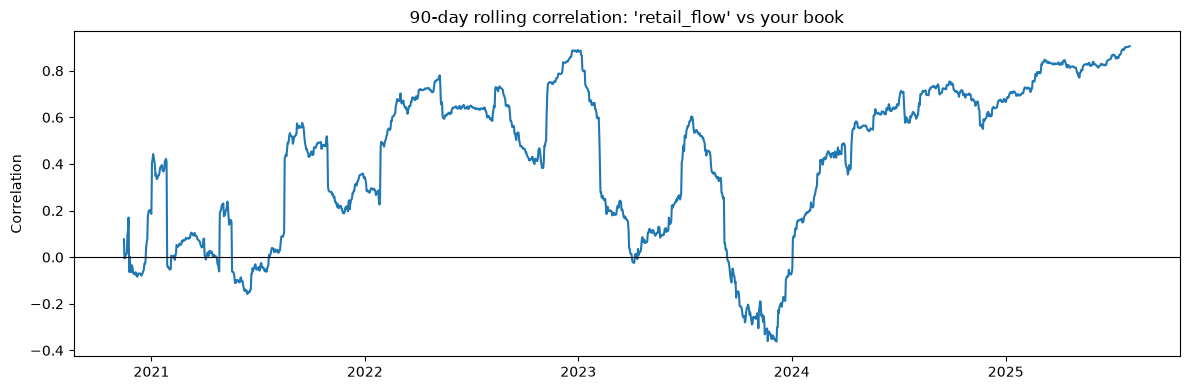

In [5]:
added_alone = build_book([FACTOR_TO_ADD], prices, factors, ALLOCATION_CAP)

pair = pd.concat({"existing": existing, "added": added_alone}, axis=1).dropna()
correlation = pair["existing"].corr(pair["added"])
print(f"Full-sample correlation of '{FACTOR_TO_ADD}' with your book: {correlation:.3f}")

rolling = pair["existing"].rolling(90).corr(pair["added"])
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(rolling.index, rolling.values)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"90-day rolling correlation: '{FACTOR_TO_ADD}' vs your book")
ax.set_ylabel("Correlation")
fig.tight_layout()
plt.show()

### Before and after adding the factor

Rebuild the book with the extra factor included, then compare. Because the
whole book is re-weighted, this is a genuine reconstruction -- not a fixed
overlay -- so the new factor competes for risk alongside the rest.

/tmp/ipykernel_2776/4031194913.py:99: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change()


                CAGR    Vol  Sharpe  Max drawdown
Existing book 0.1502 0.5164  0.5280       -0.7067
+ retail_flow 0.1705 0.5093  0.5628       -0.6637


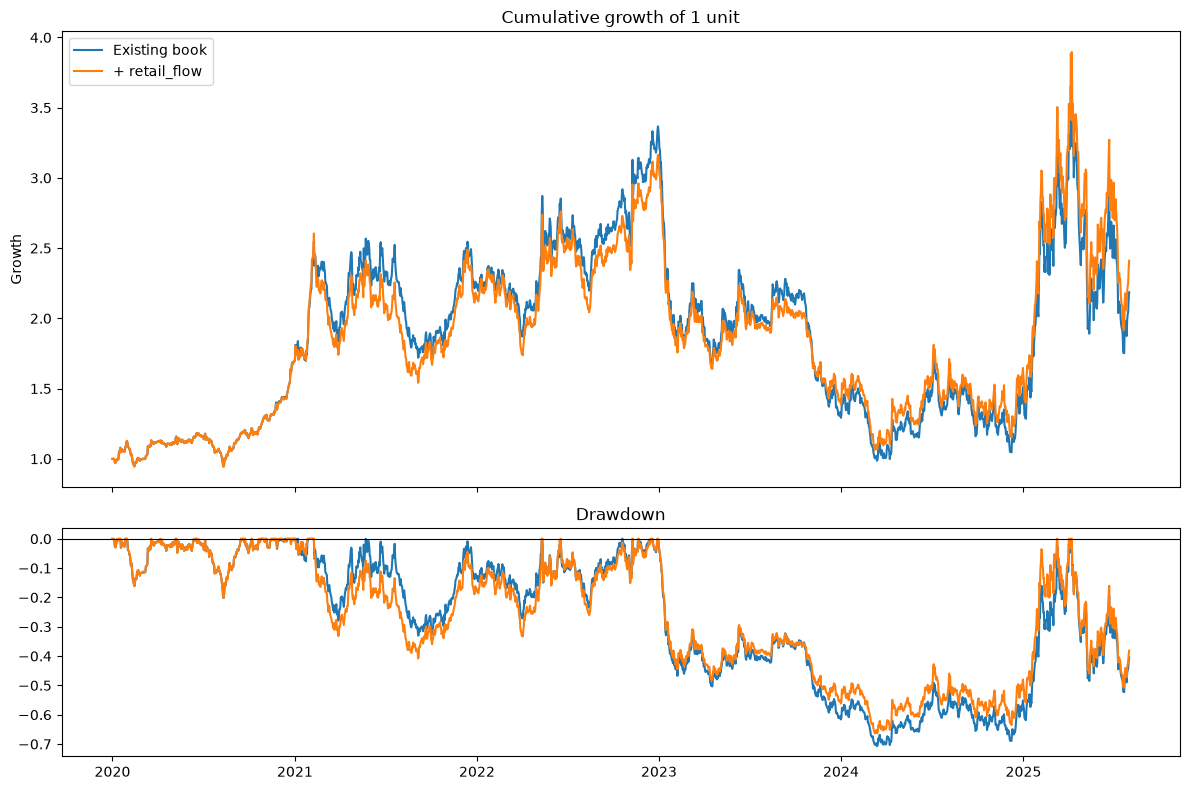

In [6]:
combined = build_book(BASE_FACTORS + [FACTOR_TO_ADD], prices, factors, ALLOCATION_CAP)

stats = pd.DataFrame(
    {
        "Existing book": perf_stats(existing),
        f"+ {FACTOR_TO_ADD}": perf_stats(combined),
    }
).T[["CAGR", "Vol", "Sharpe", "Max drawdown"]]
print(stats.to_string(float_format=lambda x: f"{x:,.4f}"))

plot_growth_and_drawdown({"Existing book": existing, f"+ {FACTOR_TO_ADD}": combined})

### Takeaways

Adding a lowly-correlated factor tends to lift risk-adjusted return (Sharpe)
more than raw return, and often trims drawdown -- that diversification is the
whole case for holding more than one factor. Swap `FACTOR_TO_ADD` (and
`BASE_FACTORS`) to test any factor against your own book.

The committed copy of this notebook is rendered against the full dataset; run
it yourself and it works out of the box on the shared public **demo key**,
which serves **preview data**. Sign up for a key to work with the full history.

- Create an account and generate an API key at
  [factors.aperiodic.io](https://factors.aperiodic.io)
- Browse the factor catalog:
  [factors.aperiodic.io/catalog](https://factors.aperiodic.io/catalog)
- Licensing & data access:
  [factors.aperiodic.io/booking](https://factors.aperiodic.io/booking)